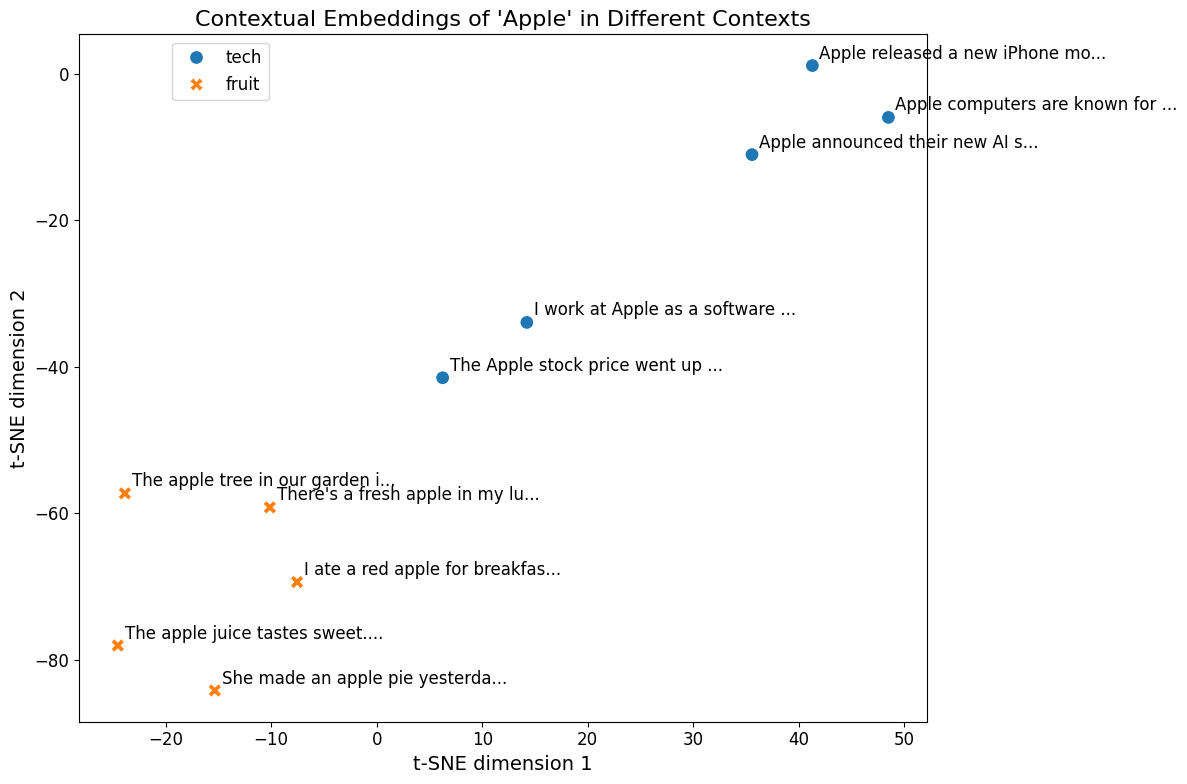


Cosine similarity between tech and fruit contexts: 0.5128
Tech context: I work at Apple as a software engineer.
Fruit context: I ate a red apple for breakfast.


In [ ]:
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def get_bert_embeddings(sentences, target_word):
    # Load pre-trained model tokenizer and model
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')
    model.eval()

    # Lists to store embeddings and their labels
    word_embeddings = []
    contexts = []

    for sentence in sentences:
        # Tokenize the sentence
        tokens = tokenizer.encode(sentence, return_tensors='pt')

        # Get BERT embeddings
        with torch.no_grad():
            outputs = model(tokens)
            embeddings = outputs.last_hidden_state.squeeze(0)

        # Convert tokens to words
        words = tokenizer.convert_ids_to_tokens(tokens[0])

        # Find the position(s) of the target word
        for idx, word in enumerate(words):
            if target_word in word:
                # Store the embedding
                word_embeddings.append(embeddings[idx].numpy())
                contexts.append(sentence)

    return np.array(word_embeddings), contexts

# Define sentences with different contexts for "apple"
sentences = [
    "I work at Apple as a software engineer.",
    "Apple released a new iPhone model.",
    "The Apple stock price went up today.",
    "I ate a red apple for breakfast.",
    "She made an apple pie yesterday.",
    "The apple juice tastes sweet.",
    "Apple computers are known for their design.",
    "There's a fresh apple in my lunchbox.",
    "Apple announced their new AI strategy.",
    "The apple tree in our garden is blooming."
]

# Get embeddings
embeddings, contexts = get_bert_embeddings(sentences, "apple")

# Use t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=3)
embeddings_2d = tsne.fit_transform(embeddings)

# Create labels for the plot (tech vs. fruit context)
labels = ['tech' if any(keyword in context.lower() for keyword in ['work', 'released', 'stock', 'computers', 'announced'])
          else 'fruit' for context in contexts]

# Plot the embeddings
plt.figure(figsize=(12, 8))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, style=labels, s=100)

# Add annotations
for i, context in enumerate(contexts):
    plt.annotate(context[:30] + "...", (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                xytext=(5, 5), textcoords='offset points', fontsize=12)

# Show legent on the top left
plt.legend(bbox_to_anchor=(0.1, 1), loc='upper left')

plt.title("Contextual Embeddings of 'Apple' in Different Contexts")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

# Print cosine similarity between some example pairs
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Compare tech context vs fruit context
tech_idx = labels.index('tech')
fruit_idx = labels.index('fruit')
similarity = cosine_similarity(embeddings[tech_idx], embeddings[fruit_idx])
print(f"\nCosine similarity between tech and fruit contexts: {similarity:.4f}")

# Print the contexts being compared
print(f"Tech context: {contexts[tech_idx]}")
print(f"Fruit context: {contexts[fruit_idx]}")

In [ ]:
from collections import defaultdict, Counter
from typing import List, Dict, Tuple, Set
import re

class BPETokenizer:
    def __init__(self, vocab_size: int):
        self.vocab_size = vocab_size
        self.vocab = set()  # Final vocabulary
        self.merge_rules = []  # List of merge rules

    def get_stats(self, words: List[List[str]]) -> Counter:
        """Count frequency of adjacent pairs in current vocabulary."""
        pairs = Counter()
        for word in words:
            for i in range(len(word) - 1):
                pairs[tuple(word[i:i+2])] += 1
        return pairs

    def merge_vocab(self, words: List[List[str]], pair: Tuple[str, str]) -> List[List[str]]:
        """Apply a merge rule to all words."""
        new_words = []
        bigram = ' '.join(pair)
        replacement = ''.join(pair)

        for word in words:
            # Convert word to space-separated string for easier replacement
            w = ' '.join(word)
            # Replace all occurrences of the bigram
            w = re.sub(f'(?<!\S){bigram}(?!\S)', replacement, w)
            new_words.append(w.split())

        return new_words

    def fit(self, text: str, num_merges: int = None) -> None:
        """Learn BPE merge rules from text."""
        if num_merges is None:
            num_merges = self.vocab_size

        # Preprocess text: split into words and characters
        words = [list(word) for word in text.split()]

        # Initialize vocabulary with characters
        self.vocab = set(char for word in words for char in word)

        # Main BPE loop
        for i in range(num_merges):
            # Get pair frequencies
            pair_freqs = self.get_stats(words)
            if not pair_freqs:
                break

            # Find most frequent pair
            best_pair = max(pair_freqs.items(), key=lambda x: (x[1], x[0]))[0]

            # Add merged token to vocabulary
            merged_token = ''.join(best_pair)
            self.vocab.add(merged_token)

            # Store merge rule
            self.merge_rules.append(best_pair)

            # Apply merge rule to all words
            words = self.merge_vocab(words, best_pair)

            if len(self.vocab) >= self.vocab_size:
                break

    def tokenize(self, text: str) -> List[str]:
        """Tokenize text using learned merge rules."""
        words = [list(word) for word in text.split()]

        for pair in self.merge_rules:
            words = self.merge_vocab(words, pair)

        return [token for word in words for token in word]

# Example usage
if __name__ == "__main__":
    # Sample text
    text = "low lower lowest flow flower flowing"

    # Initialize tokenizer
    tokenizer = BPETokenizer(vocab_size=15)

    # Train tokenizer
    tokenizer.fit(text)

    # Print vocabulary and merge rules
    print("Vocabulary:", sorted(tokenizer.vocab))
    print("\nMerge rules:")
    for i, rule in enumerate(tokenizer.merge_rules, 1):
        print(f"{i}. {rule[0]} + {rule[1]} → {''.join(rule)}")

    # Test tokenization
    test_text = "lower flower"
    tokens = tokenizer.tokenize(test_text)
    print(f"\nTokenizing '{test_text}':")
    print("Tokens:", tokens)

Vocabulary: ['e', 'f', 'g', 'i', 'l', 'low', 'lowe', 'lower', 'n', 'o', 'ow', 'r', 's', 't', 'w']

Merge rules:
1. o + w → ow
2. l + ow → low
3. low + e → lowe
4. lowe + r → lower

Tokenizing 'lower flower':
Tokens: ['lower', 'f', 'lower']


In [ ]:
import torch
from transformers import BertModel, BertTokenizer

# Initialize tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

text = "Example sentence to extract embeddings from."

# Method 1: Last Hidden State (Default)
# Returns embeddings for each token in the sequence
# Shape: [batch_size, sequence_length, hidden_size]
# Best for: Token-level tasks like NER or when you need context-aware representations for each token

def get_last_hidden_state(text):
    # Tokenize and convert to tensor
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Get model outputs
    outputs = model(**inputs)

    # Get last hidden state
    last_hidden_state = outputs.last_hidden_state
    return last_hidden_state

# Method 2: Mean Pooling
# Averages all token embeddings, weighted by attention mask
# Shape: [batch_size, hidden_size]
# Best for: General-purpose sentence embeddings
# Often performs better than CLS for semantic similarity tasks

def get_mean_pooling(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    outputs = model(**inputs)

    # Get attention mask
    attention_mask = inputs['attention_mask']

    # Mean pooling
    token_embeddings = outputs.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    mean_embedding = torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
    return mean_embedding

# Method 3: All Layer Embeddings
def get_all_layer_embeddings(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Set output_hidden_states=True to get all layer outputs
    outputs = model(**inputs, output_hidden_states=True)

    # Get all hidden states
    all_hidden_states = outputs.hidden_states
    return all_hidden_states

# Method 4: CLS Token Embedding
def get_cls_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    outputs = model(**inputs)

    # Get CLS token embedding (first token)
    cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding

# Method 5: Custom Layer Concatenation
def get_concatenated_last_n_layers(text, n_layers=4):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    outputs = model(**inputs, output_hidden_states=True)

    # Get last n hidden states
    hidden_states = outputs.hidden_states
    last_n_layers = hidden_states[-n_layers:]

    # Concatenate last n layers
    concatenated = torch.cat(last_n_layers, dim=-1)
    return concatenated

# Usage example
if __name__ == "__main__":
    # Get embeddings using different methods
    last_hidden = get_last_hidden_state(text)
    cls_embed = get_cls_embedding(text)
    mean_embed = get_mean_pooling(text)
    all_layers = get_all_layer_embeddings(text)
    concat_layers = get_concatenated_last_n_layers(text)

    print(f"Last hidden state shape: {last_hidden.shape}")
    print(f"CLS embedding shape: {cls_embed.shape}")
    print(f"Mean pooling shape: {mean_embed.shape}")
    print(f"All layers shape: {len(all_layers)}")
    print(f"Concatenated layers shape: {concat_layers.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Last hidden state shape: torch.Size([1, 12, 768])
CLS embedding shape: torch.Size([1, 768])
Mean pooling shape: torch.Size([1, 768])
All layers shape: 13
Concatenated layers shape: torch.Size([1, 12, 3072])
